In [63]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from tensorflow.keras.applications import VGG16

In [6]:
x_train=np.loadtxt("input.csv",delimiter=",")
y_train=np.loadtxt("labels.csv",delimiter=",")
x_test=np.loadtxt("input_test.csv",delimiter=",")
y_test=np.loadtxt("labels_test.csv",delimiter=",")

In [7]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 30000)
(400, 30000)
(2000,)
(400,)


In [8]:
x_train=x_train.reshape(len(x_train),100,100,3)
y_train=y_train.reshape(len(y_train),1)
x_test=x_test.reshape(len(x_test),100,100,3)
y_test=y_test.reshape(len(y_test),1)

In [ ]:
base_model=VGG16(weights="imagenet",include_top=False,input_shape=(100,100,3))
model=Sequential([
  
     
    base_model,

    Flatten(),
    Dense(64,activation="relu"),
    Dropout(0.5),
    Dense(1,activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [ ]:
history = model.fit(x_train,y_train,epochs=20,validation_data=(x_test,y_test),batch_size=64,callbacks=[early_stop])

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Accuracy",accuracy)
print("Loss",loss)

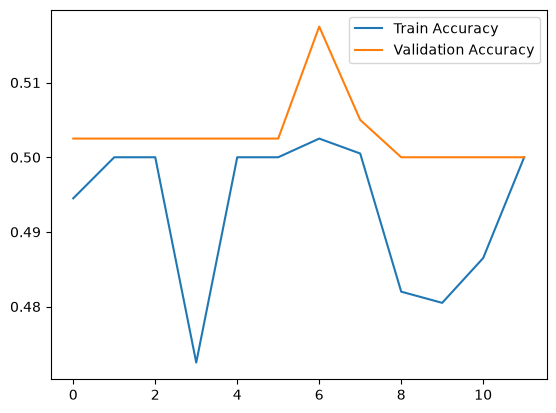

In [84]:
plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
idx2=random.randint(0,len(y_test))
plt.imshow(x_test[idx2, :]/255.0)
plt.show()
y_pred=model.predict(x_test[idx2, :].reshape(1,100,100,3))

y_pred=y_pred.round()
y_pred=y_pred>0.5
if(y_pred==1):
    print("dog")
else:
    print("cat")
print(y_pred)
